## Garch models

In [2]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error


df = pd.read_csv("silver.csv")
return_rate = 100*df["target"].dropna()

train_size = int(len(return_rate) * 0.7)
train = return_rate.iloc[:train_size]
test = return_rate.iloc[train_size:]


p-value: 3.005513795899523e-12
      lb_stat  lb_pvalue
5   10.122474   0.071838
10  19.500875   0.034343
15  25.206179   0.047242


<Figure size 1200x600 with 0 Axes>

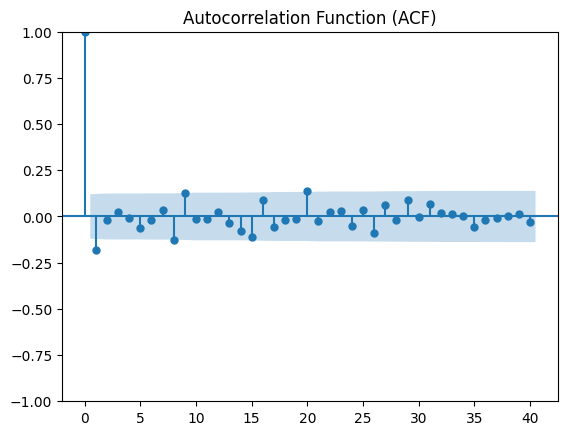

<Figure size 1200x600 with 0 Axes>

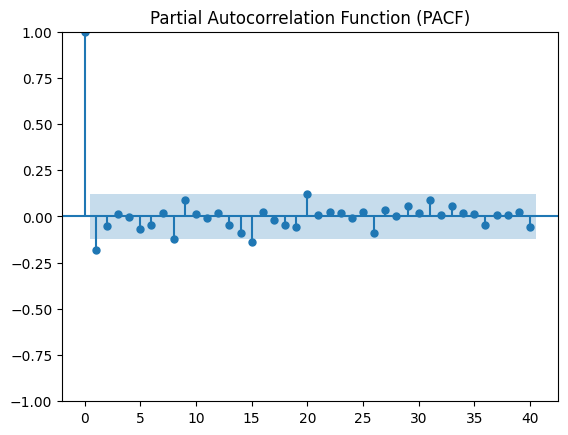

In [3]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Perform Augmented Dickey-Fuller test
result = adfuller(train)
print("p-value:", result[1])
# The timeseries appears to be stationary based on the ADF test. We can proceed with modeling the returns.

ljung_box_result = acorr_ljungbox(return_rate, lags=[5, 10, 15], return_df=True)
print(ljung_box_result)
# Not white noise, fit ARMA to the returns.

# Plot ACF
plt.figure(figsize=(12,6))
plot_acf(return_rate, lags=40)   # up to 40 lags
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plt.figure(figsize=(12,6))
plot_pacf(return_rate, lags=40, method="ywm")  # Yule-Walker method
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox


In [22]:
def arma_garch_forecast(history,mod_spec):

    meanModel = ARIMA(history, order=mod_spec[0]).fit()
    meanResiduals = meanModel.resid
    ljung_box = acorr_ljungbox(meanResiduals, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None
        
    fitted = arch_model(meanResiduals, mean="Zero", vol="GARCH", p=mod_spec[1], o=0, q=mod_spec[2], dist=mod_spec[3]).fit(disp="off")

    # Test model adequacy 
    residuals = fitted.resid
    cond_vol = fitted.conditional_volatility
    std_resid = residuals / cond_vol
    std_resid2 = (residuals**2) / cond_vol

    ljung_box = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None

    ljung_box = acorr_ljungbox(std_resid2, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        return None

    forecast = fitted.forecast(horizon=1,reindex=False)
     
    return forecast

In [24]:

lags = [(0,0,0),(1,0,0),(0,0,1),(2,0,0),(0,0,2),(1,0,1),(2,0,1),(1,0,2)]
p_vals = range(1,4)
q_vals = range(1,4)
dists = ["normal", "t"]
candidate_models = list(itertools.product(lags, p_vals, q_vals, dists))

k = 10
validation_size = train_size // (k + 1)
cv_results = []

for spec in candidate_models:
    mean_fold_errors = []
    var_fold_errors = []

    for fold in range(k):
        train_end = validation_size * (fold + 1)
        cv_train = train.iloc[:train_end]
        cv_valid = train.iloc[train_end:train_end + validation_size]

        if len(cv_valid) == 0:
            continue

        pred_var=[]
        pred_mean=[]
        history = cv_train.copy(deep=True)
        for t in range(len(cv_valid)): 
            forecast = arma_garch_forecast(history, spec)
            
            history = pd.concat([
                history,
                pd.Series([cv_valid.iloc[t]],index=[len(history)])
            ])

            if forecast is None:
                pred_var.append(pred_var[-1] if pred_var else 0)
                pred_mean.append(pred_mean[-1] if pred_mean else 0)
                continue

            pred_var.append(forecast.variance.values[-1])
            pred_mean.append(forecast.mean.values[-1])


        # Realized variance proxy
        realized_var = cv_valid.values**2
            
        var_fold_errors.append(mean_squared_error(realized_var, pred_var))
        mean_fold_errors.append(mean_squared_error(cv_valid.values, pred_mean))
    
        mean_avg_error = np.mean(mean_fold_errors)
        var_avg_error = np.mean(var_fold_errors)
            
        cv_results.append({
                "model": spec,
                "mean_cv_mse": mean_avg_error,
                "var_cv_mse": var_avg_error
           })    

        print(f"Average CV MSE = {mean_avg_error:.6f}, {var_avg_error:.6f}")


Average CV MSE = 1.693201, 10.597261
Average CV MSE = 1.729894, 14.330563
Average CV MSE = 1.564882, 10.529273
Average CV MSE = 1.820207, 9.596542
Average CV MSE = 2.054459, 11.252806
Average CV MSE = 4.413565, 102.521909
Average CV MSE = 4.560653, 101.925266
Average CV MSE = 4.791820, 107.567483
Average CV MSE = 6.832575, 253.097615
Average CV MSE = 8.796639, 370.087364
Average CV MSE = 1.693201, 10.882908
Average CV MSE = 1.729894, 12.570904
Average CV MSE = 1.564882, 9.126653
Average CV MSE = 1.820207, 8.366524
Average CV MSE = 2.054459, 10.068455
Average CV MSE = 4.413565, 102.435732
Average CV MSE = 4.560653, 101.851399
Average CV MSE = 4.791820, 107.502850
Average CV MSE = 6.832575, 253.040163
Average CV MSE = 8.796639, 370.035657
Average CV MSE = 1.693201, 10.859902
Average CV MSE = 1.729894, 13.355559
Average CV MSE = 1.564882, 9.865245
Average CV MSE = 1.820207, 9.092373
Average CV MSE = 2.054459, 10.888471
Average CV MSE = 4.413565, 102.574492
Average CV MSE = 4.560653, 101.9

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (16,) + inhomogeneous part.

In [27]:
#Find best model in regards to mean forecast performance 
best_mean_result = min(cv_results, key=lambda x: x["mean_cv_mse"])
best_mean_spec = best_mean_result["model"]

predicted_mean = []
realized_mean = []

history = train.copy(deep=True)

for t in range(len(test)):
    forecast = arma_garch_forecast(history, best_mean_spec)

    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])

    if forecast is None:
        predicted_mean.append(predicted_mean[-1] if predicted_mean else 0)
        continue

    predicted_mean.append(forecast.mean.values[-1])


mean_test_mse = mean_squared_error(test.values,predicted_mean)

print("\nTest Set Performance for mean forecast")
print(f"Test MSE  : {mean_test_mse:.6f}")



Test Set Performance for mean forecast
Test MSE  : 14.866205


In [35]:
#Find best model in regards to volatility forecast performance 
best_var_result = min(cv_results, key=lambda x: x["var_cv_mse"])
best_var_spec = best_var_result["model"]

predicted_var = []
realized_var = []

history = train.copy(deep=True)

for t in range(len(test)):
    forecast = arma_garch_forecast(history, best_var_spec)

    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])

    if forecast is None:
        predicted_var.append(predicted_var[-1] if predicted_var else 0)
        continue

    predicted_var.append(forecast.variance.values[-1])

# Realized variance proxy
var_test_mse = mean_squared_error(test.values**2,predicted_var)

print("\nTest Set Performance for volatility forecast")
print(f"Test MSE  : {var_test_mse:.6f}")



Test Set Performance for volatility forecast
Test MSE  : 1123.640858


## XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[200,500,1000],
    "subsample":[0.8, 1.0],
    "colsample_bytree":[0.8, 1.0]
}

In [ ]:
mean_features = [
    *[f"return_lag_{i}" for i in range(1,5)],
    "momentum_7",
    "momentum_14",
    "MA_ratio_short",
    "sp500_returns",
    "gold_returns",
    "fx_returns",
    "vix_changes",
    "gold_silver_ratio",
    "gold_fx_interaction",
    "US_Interest_Rate",
    "US_10Y_Yield"    
]

vol_features = [
    "volatility_7",
    "volatility_14",
    "volatility_ratio",
    "realized_vol_21",
    "realized_vol_63",
    "gold_vol_21",
    "sp500_vol_21",
    "fx_volatility"
    "gold_returns",
    "fx_returns",
    "vix_changes",
    "VIX",
    "US_10Y_Yield" 
    *[f"abs_return_lag_{i}" for i in range(1,5)] 
]

In [ ]:
X_train = train[features]
y_train = train["target_return"]

grid_return = GridSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),

    param_grid=param_grid,

    cv=tscv,

    scoring="neg_mean_squared_error",

    n_jobs=-1
)

grid_return.fit(
    X_train,
    y_train
)

best_return_model = (
    grid_return.best_estimator_
)

print(grid_return.best_params_)

In [ ]:
y_train_vol = train["target_vol"]

grid_vol = GridSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),

    param_grid=param_grid,

    cv=tscv,

    scoring="neg_mean_squared_error",

    n_jobs=-1
)

grid_vol.fit(
    X_train,
    y_train_vol
)

best_vol_model = (
    grid_vol.best_estimator_
)

print(grid_vol.best_params_)

In [ ]:
from sklearn.metrics import mean_squared_error

X_test = test[features]

y_test = test["target_return"]

pred_return = (
    best_return_model.predict(X_test)
)

rmse_return = np.sqrt(
    mean_squared_error(
        y_test,
        pred_return
    )
)

print("Return RMSE")
print(rmse_return)

In [ ]:
y_test_vol = test["target_vol"]

pred_vol = (
    best_vol_model.predict(X_test)
)

rmse_vol = np.sqrt(
    mean_squared_error(
        y_test_vol,
        pred_vol
    )
)

print("Volatility RMSE")
print(rmse_vol)